In [1]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import pandas as pd

df = pd.read_csv("../../dataset/06_model_dataset/model_data.csv")
X = df.drop(columns=['target'])
y = df['target']

# Stratified split preserves churn ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compensate for class imbalance — churners are rarer but more important to detect
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,          # Shallow trees = less overfitting
    learning_rate=0.1,
    subsample=0.8,        # Use 80% of rows per tree — reduces variance
    colsample_bytree=0.8, # Use 80% of features per tree — reduces variance
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train, y_train)
print("Model training complete.")

Class imbalance ratio (scale_pos_weight): 7.99
Model training complete.


In [2]:
# if ''

In [3]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# F1 = harmonic mean of precision and recall — best single metric for imbalanced classification
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (maximises F1): {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

Best Threshold (maximises F1): 0.8104
Best F1 Score: 0.8613


In [4]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y_prob = model.predict_proba(X_test)[:, 1]

# Adjust threshold based on business need:
# Lower → catch more churners (higher recall, more false alarms)
# Higher → fewer false alarms (higher precision, miss more churners)
threshold = 0.05

y_pred = (y_prob > threshold).astype(int)

print(f"Threshold used: {threshold}")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))



# SAVE AS TABLE
# Convert X_test to DataFrame (if it's not already)
X_test_df = pd.DataFrame(X_test)

# Create results table
results_df = X_test_df.copy()
results_df['y_actual'] = y_test.values
results_df['y_pred'] = y_pred
results_df['y_prob'] = y_prob

results_df.to_csv("../../dataset/07_powerbi/bi_prediction.csv")




Threshold used: 0.05
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     20245
           1       0.38      0.99      0.55      2534

    accuracy                           0.82     22779
   macro avg       0.69      0.89      0.72     22779
weighted avg       0.93      0.82      0.85     22779

ROC AUC: 0.9885075641076373


In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Convert to table format
cm_df = pd.DataFrame(cm, 
                     index=['Actual_0', 'Actual_1'], 
                     columns=['Pred_0', 'Pred_1'])

# Save
cm_df.to_csv("../../dataset/07_powerbi/confusion_matrix.csv")

In [6]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_df = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr,
    'Threshold': thresholds
})

roc_df.to_csv("../../dataset/07_powerbi/roc_curve.csv", index=False)

In [7]:
auc_value = roc_auc_score(y_test, y_prob)

auc_df = pd.DataFrame({
    'Metric': ['ROC_AUC'],
    'Value': [auc_value]
})

auc_df.to_csv("../../dataset/07_powerbi/auc_score.csv", index=False)

In [8]:
# sample_non_churn_full = {
#  'Discount_Amount': 0.0, 'Sustainability_Score': 9.5, 'Auto_Renewal_Score': 9,
#  'Status_Scores': 9, 'Anchoring_Score': 9.0, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 2, 'Payment_Timeframe': 0.0, 'Current_Auto_Renewal_Flag': 1,
#  'Current_World_Pay_Token': 1, 'Renewal_Score_At_Release': 27.0, 'Tenure_Years': 5,
#  'Total_Net_Paid': 700, 'Serious_Complaint_renewal': 0,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 0, 'Call_Reschedule_Request_renewal': 0,
#  'Explicit_Competitor_Mention_renewal': 0, 'Price_Switching_Mentioned_renewal': 0,
#  'Explicit_Switching_Intent_flag': 0, 'Discount_Offered_flag': 0,
#  'Customer_Response_flag': 0, 'cancel_flag': 0, 'Call_attend_status_renewal': 1,
#  'competitor_mentioned_flag': 0, 'topic_customer_flag': 0,
#  'stage_high_risk_flag': 0, 'stage_low_risk_flag': 1, 'agent_complaint_flag': 0,
#  'Band_Band B': 0, 'Band_Band C1': 0, 'Band_Band C2': 0, 'Band_Band D': 1,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 0, 'Connection_Group_3': 1,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 0, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 1, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 0, 'Anchor_Group_3': 1,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 0,
#  'Competitor_Value_Comparison_renewal_unknown': 1,
#  'Customer_Response_Risk_Low Risk': 1, 'Customer_Response_Risk_Medium Risk': 0,
#  'Customer_Response_Risk_Neutral': 0
# }

# sample_churn_strong = {
#  'Discount_Amount': 50.0, 'Sustainability_Score': 6.0, 'Auto_Renewal_Score': 5,
#  'Status_Scores': 0, 'Anchoring_Score': 6.5, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 0, 'Payment_Timeframe': 5.0, 'Current_Auto_Renewal_Flag': 0,
#  'Current_World_Pay_Token': 0, 'Renewal_Score_At_Release': 20.0, 'Tenure_Years': 1,
#  'Total_Net_Paid': 200, 'Serious_Complaint_renewal': 1,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 1, 'Call_Reschedule_Request_renewal': 1,
#  'Explicit_Competitor_Mention_renewal': 1, 'Price_Switching_Mentioned_renewal': 1,
#  'Explicit_Switching_Intent_flag': 1, 'Discount_Offered_flag': 1,
#  'Customer_Response_flag': 1, 'cancel_flag': 0, 'Call_attend_status_renewal': 0,
#  'competitor_mentioned_flag': 1, 'topic_customer_flag': 1,
#  'stage_high_risk_flag': 1, 'stage_low_risk_flag': 0, 'agent_complaint_flag': 1,
#  'Band_Band B': 0, 'Band_Band C1': 1, 'Band_Band C2': 0, 'Band_Band D': 0,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 1, 'Connection_Group_3': 0,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 1, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 0, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 1, 'Anchor_Group_3': 0,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 1,
#  'Competitor_Value_Comparison_renewal_unknown': 0,
#  'Customer_Response_Risk_Low Risk': 0, 'Customer_Response_Risk_Medium Risk': 1,
#  'Customer_Response_Risk_Neutral': 0
# }

# test_df = pd.DataFrame([sample_non_churn_full, sample_churn_strong])
# test_df.index = ['Non-Churn Example', 'Strong Churn Example']

# preds = model.predict(test_df)
# probs = model.predict_proba(test_df)[:, 1]

# test_df['prediction'] = preds
# test_df['churn_probability'] = probs

# print(test_df[['prediction', 'churn_probability']])

Top 20 Feature Importances:
Status_Scores                                  0.349266
Current_World_Pay_Token                        0.147674
Sustainability_Score                           0.056269
stage_high_risk_flag                           0.026992
Anchor_Group_Unknown                           0.024983
Connection_Group_Unknown                       0.023949
Current_Auto_Renewal_Flag                      0.023290
cancel_flag                                    0.022349
Total_Net_Paid                                 0.021148
Auto_Renewal_Score                             0.021006
Discount_Amount                                0.019216
Tenure_Years                                   0.018684
Band_Band F                                    0.016471
Tenure_Group_4+                                0.012188
Band_Band B                                    0.011889
Payment_Timeframe                              0.010289
Band_Band C1                                   0.009930
Renewal_Score_At_Rel

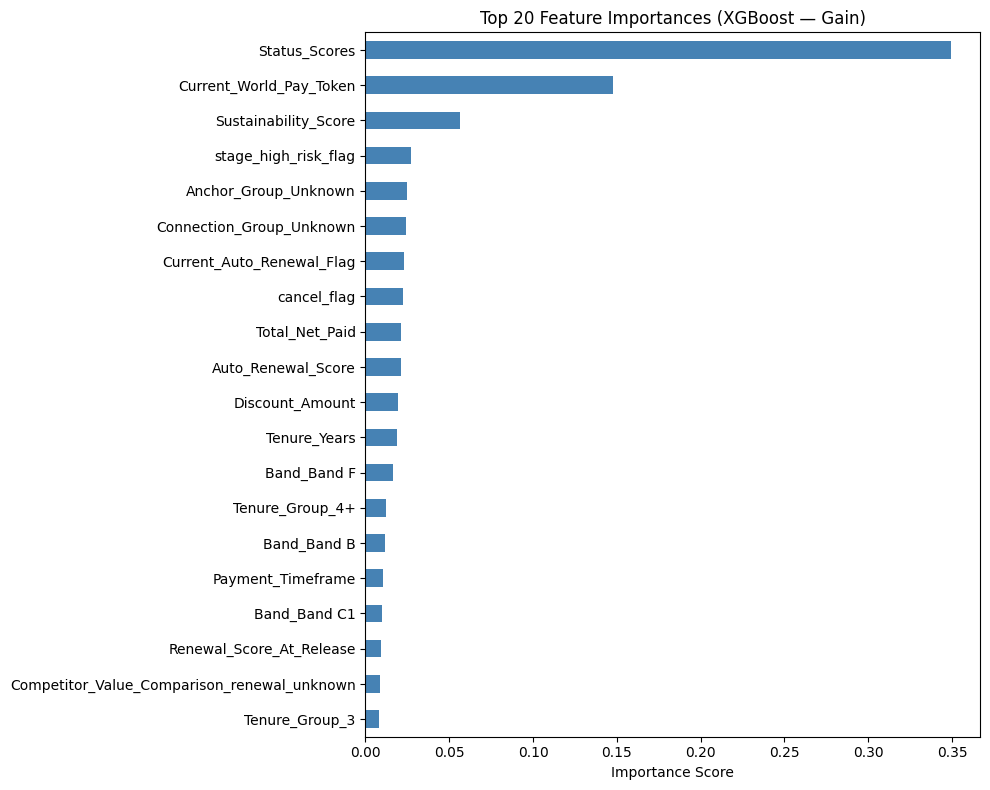

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20)

print("Top 20 Feature Importances:")
print(top_features)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances (XGBoost — Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# SAVE AS TABLE


# Convert Series to DataFrame
feature_importance_df = top_features.reset_index()

# Rename columns
feature_importance_df.columns = ['Feature', 'Importance']

# Save to CSV
feature_importance_df.to_csv("../../dataset/07_powerbi/feature_importance.csv", index=False)

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


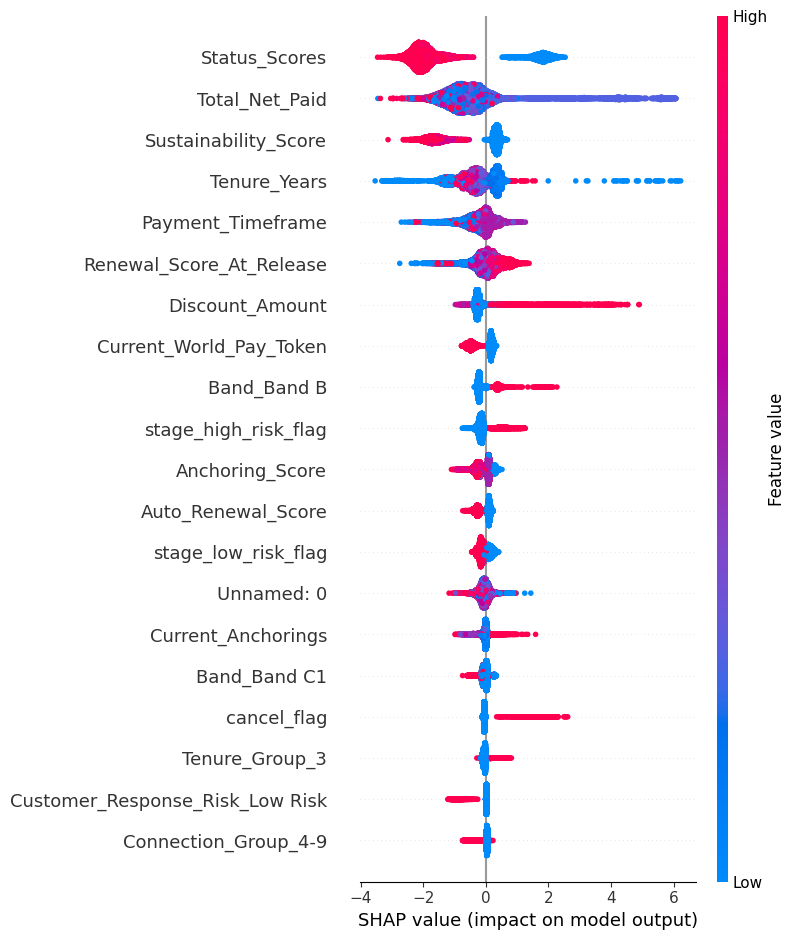

SHAP datasets saved successfully 🚀


In [10]:
# =========================
# SHAP EXPLAINABILITY
# =========================
import shap
import pandas as pd
import numpy as np

# -------------------------
# 1. Create SHAP Explainer
# -------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# =========================
# 2. GLOBAL SHAP IMPORTANCE
# =========================
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='SHAP_Importance', ascending=False
)

# Save
shap_importance.to_csv(
    "../../dataset/07_powerbi/shap_feature_importance.csv",
    index=False
)

# =========================
# 3. ROW-LEVEL SHAP TABLE
# =========================
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Add prediction info
shap_df['y_actual'] = y_test.values
shap_df['y_pred'] = y_pred
shap_df['y_prob'] = y_prob
shap_df['threshold'] = best_threshold

# Save
shap_df.to_csv(
    "../../dataset/07_powerbi/shap_row_level.csv",
    index=False
)

# =========================
# 4. TOP FEATURES PER ROW
# =========================
def get_top_features(row, top_n=3):
    return list(row.abs().sort_values(ascending=False).head(top_n).index)

shap_df['top_3_features'] = shap_df[X_test.columns].apply(get_top_features, axis=1)

# Save compact table
top_features_df = shap_df[['y_actual', 'y_pred', 'y_prob', 'top_3_features']]

top_features_df.to_csv(
    "../../dataset/07_powerbi/shap_top_features.csv",
    index=False
)

# =========================
# 5. OPTIONAL VISUALS
# =========================
# Global summary plot
shap.summary_plot(shap_values, X_test)

# Individual explanation (first row)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

print("SHAP datasets saved successfully 🚀")

In [11]:
# pip install llvmlite==0.41.1
# pip install numba==0.58.1
# pip install shap==0.44.1